In [ ]:
# Import necessary libraries
import numpy as np
import tensorflow as tf
from tensorflow.keras.datasets import mnist

# Step 1: Load the MNIST dataset
(x_train, y_train), (x_test, y_test) = mnist.load_data()

# Step 2: Combine the training and test data into a single dataset
# Reshape the data into (n_samples, n_features) format
data = np.concatenate((x_train, x_test), axis=0)
labels = np.concatenate((y_train, y_test), axis=0)

# Flatten the images to a 2D array: (n_samples, 28*28)
data = data.reshape(data.shape[0], -1)

# Step 3: Shuffle the dataset
m, n = data.shape
# Stack the data with labels and shuffle them together
data_labels = np.hstack((labels.reshape(m, 1), data))
np.random.shuffle(data_labels)

# Step 4: Split into development and training sets
data_dev = data_labels[:1000].T  # First 1000 samples for development
Y_dev = data_dev[0]
X_dev = data_dev[1:n+1] / 255.  # Normalize X_dev to the range [0, 1]

data_train = data_labels[1000:].T  # Remaining data for training
Y_train = data_train[0]
X_train = data_train[1:n+1] / 255.  # Normalize X_train to the range [0, 1]

# Step 5: Get the dimensions of the training set
_, m_train = X_train.shape

# Print the results
print("Shape of X_dev:", X_dev.shape)
print("Shape of Y_dev:", Y_dev.shape)
print("Shape of X_train:", X_train.shape)
print("Shape of Y_train:", Y_train.shape)
print("Number of training samples:", m_train)



11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
Shape of X_dev: (784, 1000)
Shape of Y_dev: (1000,)
Shape of X_train: (784, 69000)
Shape of Y_train: (69000,)
Number of training samples: 69000


In [ ]:
def init_params():
    w1 = np.random.rand(10, 784) - 0.5  # First hidden layer
    b1 = np.random.rand(10, 1) - 0.5
    w2 = np.random.rand(10, 10) - 0.5  # Second hidden layer
    b2 = np.random.rand(10, 1) - 0.5
    w3 = np.random.rand(10, 10) - 0.5  # Output layer (10 neurons for 10 classes)
    b3 = np.random.rand(10, 1) - 0.5
    return w1, b1, w2, b2, w3, b3


def ReLU(Z):
    return np.maximum(Z, 0)

def softmax(Z):
    A=np.exp(Z) / sum(np.exp(Z))
    return A

def forward_prop(w1, b1, w2, b2, w3, b3, X):
    z1 = w1.dot(X) + b1     # Compute the weighted sum of inputs (first hidden layer)
    a1 = ReLU(z1)           # Apply ReLU activation function to first hidden layer
    z2 = w2.dot(a1) + b2    # Compute the weighted sum for second hidden layer
    a2 = ReLU(z2)           # Apply ReLU activation function to second hidden layer
    z3 = w3.dot(a2) + b3    # Compute the weighted sum for output layer
    a3 = softmax(z3)        # Apply softmax activation function to output layer
    return z1, a1, z2, a2, z3, a3


def one_hot(Y):
    one_hot_Y = np.zeros((Y.size, Y.max() + 1))
    one_hot_Y[np.arange(Y.size), Y] = 1
    one_hot_Y = one_hot_Y.T
    return one_hot_Y

def deriv_ReLU(Z):
    return Z>0

def back_prop(z1, a1, z2, a2, z3, a3, w2, w3, Y, X):
    OneHot_Y = one_hot(Y)           # Convert labels to one-hot encoding
    dZ3 = a3 - OneHot_Y             # Compute the error for the output layer (a3 - OneHot_Y)
    dW3 = 1 / m * dZ3.dot(a2.T)     # Gradient for weights of output layer
    db3 = 1 / m * np.sum(dZ3)       # Gradient for biases of output layer

    dZ2 = w3.T.dot(dZ3) * deriv_ReLU(z2)   # Compute the error for second hidden layer
    dW2 = 1 / m * dZ2.dot(a1.T)           # Gradient for weights of second hidden layer
    db2 = 1 / m * np.sum(dZ2)             # Gradient for biases of second hidden layer

    dZ1 = w2.T.dot(dZ2) * deriv_ReLU(z1)   # Compute the error for first hidden layer
    dW1 = 1 / m * dZ1.dot(X.T)             # Gradient for weights of first hidden layer
    db1 = 1 / m * np.sum(dZ1)              # Gradient for biases of first hidden layer

    return dW1, db1, dW2, db2, dW3, db3


def update_params(W1, b1, W2, b2, W3, b3, dW1, db1, dW2, db2, dW3, db3, alpha):
    W1 = W1 - alpha * dW1  # Update weights for the first hidden layer
    b1 = b1 - alpha * db1  # Update biases for the first hidden layer
    W2 = W2 - alpha * dW2  # Update weights for the second hidden layer
    b2 = b2 - alpha * db2  # Update biases for the second hidden layer
    W3 = W3 - alpha * dW3  # Update weights for the output layer
    b3 = b3 - alpha * db3  # Update biases for the output layer
    return W1, b1, W2, b2, W3, b3



def get_predictions(a2):
    return np.argmax(a2,0)

def get_accuracy(predictions, Y):
    print(predictions, Y)
    return np.sum(predictions == Y)/Y.size

def gradient_descent(X, Y, iterations, alpha):
    w1, b1, w2, b2, w3, b3 = init_params()  # Initialize the weights and biases
    for i in range(iterations):
        z1, a1, z2, a2, z3, a3 = forward_prop(w1, b1, w2, b2, w3, b3, X)
        dW1, db1, dW2, db2, dW3, db3 = back_prop(z1, a1, z2, a2, z3, a3, w2, w3, Y, X)
        w1, b1, w2, b2, w3, b3 = update_params(w1, b1, w2, b2, w3, b3, dW1, db1, dW2, db2, dW3, db3, alpha)
        if i % 10 == 0:
            print("iterations: ", i)
            print("accuracy: ", get_accuracy(get_predictions(a3), Y))
    return w1, b1, w2, b2, w3, b3




In [ ]:
w1, b1, w2, b2, w3, b3 = gradient_descent(X_train, Y_train, 500, 0.1)


iterations:  0
[7 6 6 ... 6 2 2] [8 6 6 ... 8 0 6]
accuracy:  0.12331884057971014
iterations:  10
[1 6 6 ... 4 6 6] [8 6 6 ... 8 0 6]
accuracy:  0.19592753623188405
iterations:  20
[1 6 6 ... 4 6 6] [8 6 6 ... 8 0 6]
accuracy:  0.23998550724637682
iterations:  30
[1 6 6 ... 3 6 6] [8 6 6 ... 8 0 6]
accuracy:  0.27243478260869564
iterations:  40
[1 6 6 ... 3 2 6] [8 6 6 ... 8 0 6]
accuracy:  0.31166666666666665
iterations:  50
[1 6 6 ... 3 2 0] [8 6 6 ... 8 0 6]
accuracy:  0.34833333333333333
iterations:  60
[1 6 6 ... 3 2 0] [8 6 6 ... 8 0 6]
accuracy:  0.3883913043478261
iterations:  70
[1 4 6 ... 3 2 0] [8 6 6 ... 8 0 6]
accuracy:  0.4314782608695652
iterations:  80
[1 4 6 ... 3 2 0] [8 6 6 ... 8 0 6]
accuracy:  0.47104347826086956
iterations:  90
[1 4 6 ... 3 2 0] [8 6 6 ... 8 0 6]
accuracy:  0.5076376811594203
iterations:  100
[1 4 6 ... 3 2 0] [8 6 6 ... 8 0 6]
accuracy:  0.5404927536231884
iterations:  110
[1 6 6 ... 3 2 0] [8 6 6 ... 8 0 6]
accuracy:  0.5695507246376812
iteratio

In [ ]:
def make_predictions(X, W1, b1, W2, b2, W3, b3):
    # Perform forward propagation through all 3 layers
    _, _, _, A2, _, A3 = forward_prop(W1, b1, W2, b2, W3, b3, X)

    # Use the output layer (A3) to get predictions
    predictions = get_predictions(A3)

    return predictions


In [ ]:
import matplotlib.pyplot as plt

def test_prediction(index, W1, b1, W2, b2, W3, b3):
    # Extract the image from the dataset at the given index
    current_image = X_train[:, index, None]  # Shape should be (784, 1) for a single image

    # Make predictions using the 3-layer model (now passing all weights and biases)
    prediction = make_predictions(current_image, W1, b1, W2, b2, W3, b3)

    # Get the true label from Y_train
    label = Y_train[index]

    # Print the predicted and actual label
    print(f"Prediction: {prediction}")
    print(f"Label: {label}")

    # Reshape and scale the image to 28x28 for visualization (MNIST format)
    current_image = current_image.reshape((28, 28)) * 255  # Reshape to 28x28 and scale to [0, 255]

    # Plot the image
    plt.gray()
    plt.imshow(current_image, interpolation='nearest')
    plt.show()


Prediction: [8]
Label: 8


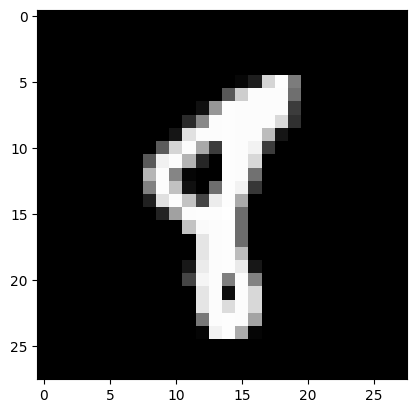

Prediction: [6]
Label: 6


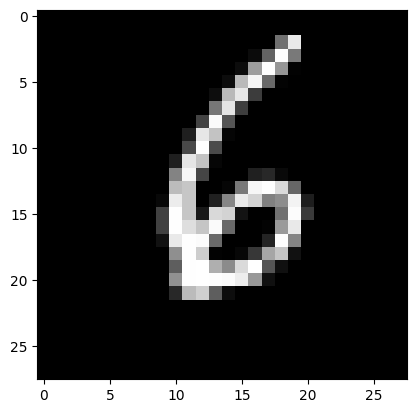

Prediction: [5]
Label: 6


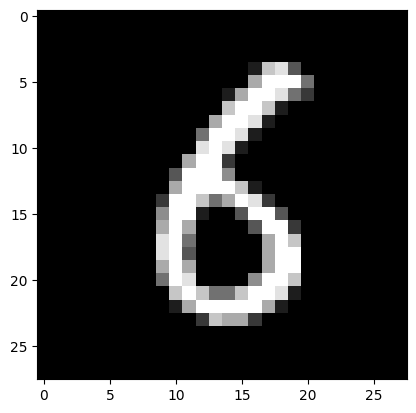

Prediction: [8]
Label: 5


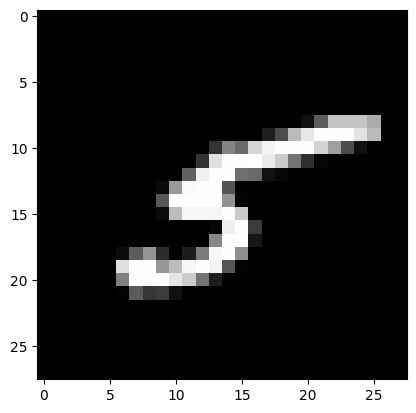

In [ ]:
test_prediction(0, w1, b1, w2, b2, w3, b3)
test_prediction(1, w1, b1, w2, b2, w3, b3)
test_prediction(2, w1, b1, w2, b2, w3, b3)
test_prediction(3, w1, b1, w2, b2, w3, b3)


In [ ]:
# Use the three-layer network for making predictions on the development set
dev_predictions = make_predictions(X_dev, w1, b1, w2, b2, w3, b3)

# Get the accuracy of the predictions
accuracy = get_accuracy(dev_predictions, Y_dev)

# Print the accuracy
print(f"Development Set Accuracy: {accuracy}")


[1 8 2 9 4 4 1 2 4 5 3 5 1 8 3 8 0 9 2 4 2 6 1 1 6 2 5 1 9 4 8 5 7 6 7 8 4
 3 1 1 5 8 9 9 2 2 8 1 5 0 6 7 9 6 4 9 2 7 4 3 6 1 9 7 0 5 4 0 5 8 9 2 4 4
 6 6 5 6 4 1 2 5 5 8 9 7 6 7 1 7 7 7 2 7 1 1 6 0 4 4 1 5 9 4 8 6 0 8 2 1 6
 1 8 3 4 8 2 3 6 0 2 2 7 3 0 0 4 3 8 6 3 3 9 6 0 1 8 9 5 1 3 7 6 5 5 7 9 5
 1 8 4 2 0 9 7 3 7 3 4 6 5 8 8 2 9 0 3 9 9 5 0 8 7 0 8 2 2 2 1 9 0 6 3 5 8
 3 4 0 7 6 4 8 2 6 6 1 3 5 9 5 8 0 0 8 4 2 6 2 1 3 0 9 0 7 2 8 0 4 4 3 7 2
 9 7 3 2 2 7 7 5 6 3 9 5 9 8 6 7 6 0 9 3 0 6 8 9 7 1 4 8 7 8 0 5 7 1 3 4 0
 3 1 0 8 2 6 1 3 6 1 2 8 5 2 0 0 1 8 6 9 1 7 9 2 9 2 7 1 0 1 4 1 0 1 4 9 0
 8 5 8 1 1 1 3 3 0 0 9 7 0 0 3 6 2 6 5 5 2 6 9 1 2 4 1 1 5 8 2 5 9 4 7 6 5
 5 9 2 2 8 8 9 8 6 5 2 4 3 0 9 3 6 9 7 5 0 3 5 0 4 8 1 3 3 0 6 2 3 7 1 5 6
 8 1 8 7 0 8 7 2 3 1 5 7 1 7 9 5 2 7 7 2 3 7 3 7 6 5 8 3 1 5 9 7 5 1 4 5 7
 0 3 9 0 6 6 8 7 4 6 9 3 1 2 1 4 7 9 2 6 1 3 2 9 6 7 7 5 9 9 9 8 7 8 1 7 0
 9 4 8 8 6 7 0 3 4 7 0 1 0 4 1 1 7 1 2 7 3 3 4 7 0 3 8 1 6 6 1 9 8 7 8 9 1
 0 1 8 5 6 2 0 3 7 4 6 4 